<a href="https://colab.research.google.com/github/maheer461/sprint4-final-project/blob/main/sprint4_final_project_starter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sprint 4 Project: E-Commerce Customer Behavior EDA

Welcome to your Sprint 4 final project. In this project, you will apply everything you've learned across Sprints 1–4 to perform a complete Exploratory Data Analysis on the **Olist Brazilian E-Commerce dataset** — real data from a real e-commerce platform.


## Dataset

You'll work with 7 CSV files from the Olist e-commerce dataset:

| File | Rows | Description |
|---|---|---|
| `olist_orders_dataset.csv` | 99,441 | Orders with timestamps and status |
| `olist_order_items_dataset.csv` | 112,650 | Items per order with price and freight |
| `olist_customers_dataset.csv` | 99,441 | Customer ID, city, state |
| `olist_products_dataset.csv` | 32,951 | Products with category and dimensions |
| `olist_order_reviews_dataset.csv` | 99,224 | Review scores (1–5 stars) |
| `olist_order_payments_dataset.csv` | 103,886 | Payment type and value |
| `product_category_name_translation.csv` | 71 | Portuguese → English category names |

Let's get started!

---

## Setup

Run the cells below to import the libraries you'll need and load the datasets. The data is hosted on GitHub, so you can load it with one line of code per file — no uploads required.

In [1]:
# Import libraries
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

# Confirm versions
print(f"pandas version: {pd.__version__}")
print("Setup complete!")

pandas version: 2.2.2
Setup complete!


In [2]:
# Load the 7 datasets from the curriculum GitHub repo
BASE_URL = 'https://practicum-content.s3.us-west-1.amazonaws.com/data-analytics/eda-project/'

orders = pd.read_csv(BASE_URL + 'olist_orders_dataset.csv')
items = pd.read_csv(BASE_URL + 'olist_order_items_dataset.csv')
customers = pd.read_csv(BASE_URL + 'olist_customers_dataset.csv')
products = pd.read_csv(BASE_URL + 'olist_products_dataset.csv')
reviews = pd.read_csv(BASE_URL + 'olist_order_reviews_dataset.csv')
payments = pd.read_csv(BASE_URL + 'olist_order_payments_dataset.csv')
translation = pd.read_csv(BASE_URL + 'product_category_name_translation.csv')

print(f"orders:      {orders.shape}")
print(f"items:       {items.shape}")
print(f"customers:   {customers.shape}")
print(f"products:    {products.shape}")
print(f"reviews:     {reviews.shape}")
print(f"payments:    {payments.shape}")
print(f"translation: {translation.shape}")

orders:      (99441, 8)
items:       (112650, 7)
customers:   (99441, 5)
products:    (32951, 9)
reviews:     (99224, 7)
payments:    (103886, 5)
translation: (71, 2)


In [3]:
# Set up an in-memory SQLite database with all 7 tables
# This lets you run SQL queries directly against the DataFrames
conn = sqlite3.connect(':memory:')

orders.to_sql('orders', conn, index=False, if_exists='replace')
items.to_sql('items', conn, index=False, if_exists='replace')
customers.to_sql('customers', conn, index=False, if_exists='replace')
products.to_sql('products', conn, index=False, if_exists='replace')
reviews.to_sql('reviews', conn, index=False, if_exists='replace')
payments.to_sql('payments', conn, index=False, if_exists='replace')
translation.to_sql('translation', conn, index=False, if_exists='replace')

print("SQLite database ready. You can now run SQL queries with pd.read_sql().")

SQLite database ready. You can now run SQL queries with pd.read_sql().


---

## Question 1: Inspect the orders DataFrame

**Your task:** For the `orders` DataFrame:
1. Print its shape
2. Print the first 5 rows with `.head()`
3. Print column info with `.info()`

This is the very first thing every analyst does with a new dataset.

*Skills: Sprint 4 Ch 01 (Pandas inspection)*

In [4]:
# 1. Print the shape (rows, columns)
print("=== Orders DataFrame Shape ===")
print(f"Rows: {orders.shape[0]:,}, Columns: {orders.shape[1]}")
print()

# 2. Print the first 5 rows
print("=== First 5 Rows ===")
print(orders.head())
print()

# 3. Print column info (dtypes and non-null counts)
print("=== Column Information ===")
orders.info()

=== Orders DataFrame Shape ===
Rows: 99,441, Columns: 8

=== First 5 Rows ===
                           order_id                       customer_id  \
0  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
1  53cdb2fc8bc7dce0b6741e2150273451  b0830fb4747a6c6d20dea0b8c802d7ef   
2  47770eb9100c2d0c44946d9cf07ec65d  41ce2a54c0b03bf3443c3d931a367089   
3  949d5b44dbf5de918fe9c16f97b45f8a  f88197465ea7920adcdbec7375364d82   
4  ad21c59c0840e6cb83a9ceb5573f8159  8ab97904e6daea8866dbdbc4fb7aad2c   

  order_status order_purchase_timestamp    order_approved_at  \
0    delivered      2017-10-02 10:56:33  2017-10-02 11:07:15   
1    delivered      2018-07-24 20:41:37  2018-07-26 03:24:27   
2    delivered      2018-08-08 08:38:49  2018-08-08 08:55:23   
3    delivered      2017-11-18 19:28:06  2017-11-18 19:45:59   
4    delivered      2018-02-13 21:18:39  2018-02-13 22:20:29   

  order_delivered_carrier_date order_delivered_customer_date  \
0          2017-10-04 19:55:00    

---

## Question 2: Clean the orders data

The `orders` DataFrame has timestamp columns stored as strings, and a few have missing values.

**Your task:**
1. Use `.isnull().sum()` to count missing values in each column of `orders`
2. Convert `order_purchase_timestamp` and `order_delivered_customer_date` to datetime using `pd.to_datetime()`
3. Print the dtypes after conversion to verify

*Skills: Sprint 4 Ch 02 (Cleaning, dtype conversion)*

In [5]:
# 1. Count missing values in each column
print("=== Missing Values Per Column ===")
print(orders.isnull().sum())
print()

# 2. Convert timestamp columns to datetime
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])
orders['order_delivered_customer_date'] = pd.to_datetime(orders['order_delivered_customer_date'])

# 3. Print dtypes after conversion to verify
print("=== Data Types After Conversion ===")
print(orders.dtypes)


=== Missing Values Per Column ===
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

=== Data Types After Conversion ===
order_id                                 object
customer_id                              object
order_status                             object
order_purchase_timestamp         datetime64[ns]
order_approved_at                        object
order_delivered_carrier_date             object
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date            object
dtype: object


---

## Question 3: Order status breakdown (SQL)

**Your task:** Write a SQL query against the `orders` table that returns:
- `order_status`
- `num_orders` — count of orders with that status
- `pct` — percentage of total orders, rounded to 2 decimals

Sort by `num_orders` descending. Save the result to a DataFrame called `status_summary` and print it.

**Hint:** Use `pd.read_sql("...", conn)`. The percentage trick is `COUNT(*) * 100.0 / (SELECT COUNT(*) FROM orders)`.

*Skills: Sprint 2 (SQL aggregation), Sprint 4 Ch 03 (Descriptive stats)*

In [6]:
query_q3 = """
SELECT
    order_status,
    COUNT(*) AS num_orders,
    ROUND(COUNT(*) * 100.0 / (SELECT COUNT(*) FROM orders), 2) AS pct
FROM orders
GROUP BY order_status
ORDER BY num_orders DESC
"""

status_summary = pd.read_sql(query_q3, conn)
print(status_summary)


  order_status  num_orders    pct
0    delivered       96478  97.02
1      shipped        1107   1.11
2     canceled         625   0.63
3  unavailable         609   0.61
4     invoiced         314   0.32
5   processing         301   0.30
6      created           5   0.01
7     approved           2   0.00


---

## Question 4: Top 10 highest-revenue orders (SQL JOIN)

Each order can have multiple items. Total order revenue = sum of `price + freight_value` across all its items.

**Your task:** Write a SQL query that JOINs `orders` and `items` to find the **10 highest-revenue orders**. Return:
- `order_id`
- `order_status`
- `total_revenue` — rounded to 2 decimals

Save the result to `top_orders` and print it.

*Skills: Sprint 2 (SQL JOIN, GROUP BY), Sprint 4 Ch 06 (combining tables)*

In [7]:
query_q4 = """
SELECT
    o.order_id,
    o.order_status,
    ROUND(SUM(i.price + i.freight_value), 2) AS total_revenue
FROM orders o
JOIN items i ON o.order_id = i.order_id
GROUP BY o.order_id, o.order_status
ORDER BY total_revenue DESC
LIMIT 10
"""

top_orders = pd.read_sql(query_q4, conn)
print(top_orders)

                           order_id order_status  total_revenue
0  03caa2c082116e1d31e67e9ae3700499    delivered       13664.08
1  736e1922ae60d0d6a89247b851902527    delivered        7274.88
2  0812eb902a67711a1cb742b3cdaa65ae    delivered        6929.31
3  fefacc66af859508bf1a7934eab1e97f    delivered        6922.21
4  f5136e38d1a14a4dbd87dff67da82701    delivered        6726.66
5  2cc9089445046817a7539d90805e6e5a    delivered        6081.54
6  a96610ab360d42a2e5335a3998b4718a    delivered        4950.34
7  b4c4b76c642808cbe472a32b86cddc95     canceled        4809.44
8  199af31afc78c699f0dbf71fb178d4d4    delivered        4764.34
9  8dbc85d1447242f3b127dda390d56e19    delivered        4681.78


---

## Question 5: English product categories (pandas merge)

The `products` table has a Portuguese category column called `product_category_name`. The `translation` table maps each Portuguese name to its English equivalent.

**Your task:**
1. Use `products.merge(translation, on='product_category_name', how='left')` to add the English column. Save it to `products_eng`.
2. Find the **top 10 categories by number of products** using `value_counts()` on the `product_category_name_english` column. Save to `top_categories` and print it.

*Skills: Sprint 4 Ch 06 (pandas merge), Ch 03 (value_counts)*

In [8]:
# 1: Merge products with translation to add English category names
products_eng = products.merge(translation, on='product_category_name', how='left')

# 2: Find top 10 categories by number of products
top_categories = products_eng['product_category_name_english'].value_counts().head(10)

# 3: Display the result
print("Top 10 Product Categories by Number of Products:")
print(top_categories)


Top 10 Product Categories by Number of Products:
product_category_name_english
bed_bath_table           3029
sports_leisure           2867
furniture_decor          2657
health_beauty            2444
housewares               2335
auto                     1900
computers_accessories    1639
toys                     1411
watches_gifts            1329
telephony                1134
Name: count, dtype: int64


---

## Question 6: Revenue and average review score by category

Now you'll combine three tables and compute multiple metrics per category.

**Your task:**
1. Build a DataFrame that merges `items` with `products_eng` (to get categories), then merges with `reviews` (to get scores). The shared key chain is: `items.product_id → products_eng.product_id` and `items.order_id → reviews.order_id`.
2. Add a `revenue` column = `price + freight_value`
3. Group by `product_category_name_english` and aggregate:
   - `total_revenue` = sum of `revenue`
   - `avg_review` = mean of `review_score`
   - `n_items` = count of `order_id`
4. Sort by `total_revenue` descending and show the **top 10 categories**. Save to `category_summary`.

*Skills: Sprint 4 Ch 06 (multi-table merge, groupby with multiple aggregations)*

In [9]:
# 1. Merge items with products_eng to get category names
items_cat = items.merge(products_eng, on='product_id', how='left')

# 2. Merge with reviews to get review scores
items_cat_reviews = items_cat.merge(reviews[['order_id', 'review_score']], on='order_id', how='left')

# 3. Add revenue column (price + freight_value)
items_cat_reviews['revenue'] = items_cat_reviews['price'] + items_cat_reviews['freight_value']

# 4. Group by category and aggregate
category_summary = items_cat_reviews.groupby('product_category_name_english').agg(
    total_revenue=('revenue', 'sum'),
    avg_review=('review_score', 'mean'),
    n_items=('order_id', 'count')
).reset_index()

# 5. Sort by total_revenue descending and get top 10
category_summary = category_summary.sort_values('total_revenue', ascending=False).head(10)

# 6. Display the result
print(category_summary)


   product_category_name_english  total_revenue  avg_review  n_items
43                 health_beauty     1446622.08    4.142768     9727
70                 watches_gifts     1306761.40    4.019160     6001
7                 bed_bath_table     1258189.51    3.895663    11270
65                sports_leisure     1163329.98    4.107986     8700
15         computers_accessories     1068070.48    3.930819     7894
39               furniture_decor      910683.05    3.903493     8415
49                    housewares      781170.03    4.055019     6989
20                    cool_stuff      721492.90    4.146341     3806
5                           auto      687374.19    4.065512     4256
42                  garden_tools      585646.54    4.042735     4361


---

## Question 7: Top 10 customer states (SQL + bar chart)

**Your task:**
1. Write a SQL query that returns the **top 10 customer states** by number of customers. Columns: `customer_state`, `num_customers`. Save to `state_top10`.
2. Create a **bar chart** of `num_customers` by `customer_state`. Add a title and rotate the x-tick labels if they overlap.

*Skills: Sprint 2 (SQL GROUP BY), Sprint 4 Ch 04 (bar chart)*

  customer_state  num_customers
0             SP          41746
1             RJ          12852
2             MG          11635
3             RS           5466
4             PR           5045
5             SC           3637
6             BA           3380
7             DF           2140
8             ES           2033
9             GO           2020


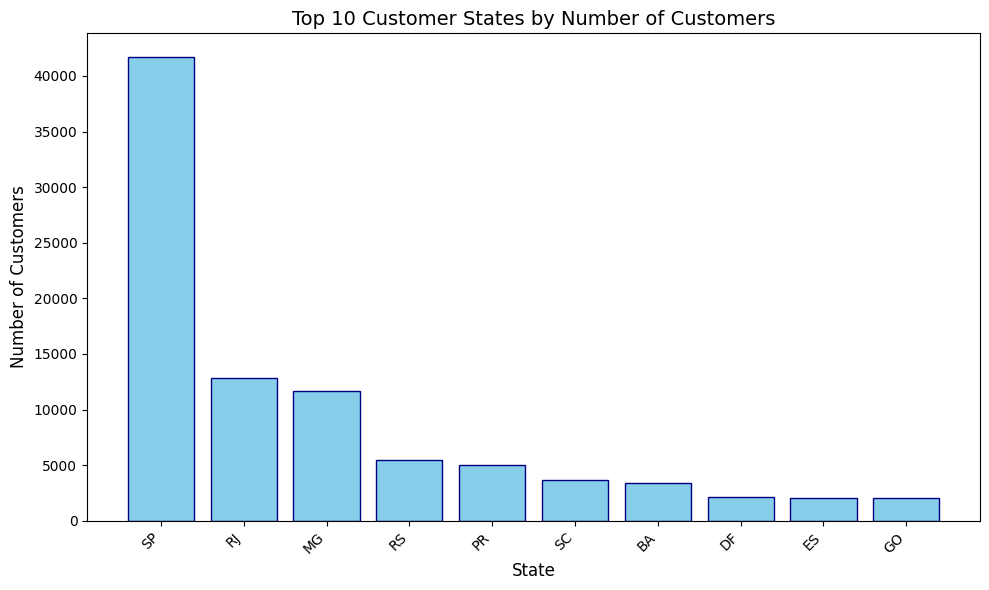

In [10]:
# 1. SQL query to get top 10 states by number of customers
query_q7 = """
SELECT
    customer_state,
    COUNT(*) AS num_customers
FROM customers
GROUP BY customer_state
ORDER BY num_customers DESC
LIMIT 10
"""

state_top10 = pd.read_sql(query_q7, conn)
print(state_top10)

# 2. Create bar chart
plt.figure(figsize=(10, 6))
plt.bar(state_top10['customer_state'], state_top10['num_customers'], color='skyblue', edgecolor='navy')
plt.title('Top 10 Customer States by Number of Customers', fontsize=14)
plt.xlabel('State', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


---

## Question 8: Monthly order trend (line chart)

**Your task:**
1. From the cleaned `orders` DataFrame (with datetime columns from Q2), extract a `year_month` period from `order_purchase_timestamp` using `.dt.to_period('M')`
2. Count orders per month — save to a DataFrame called `monthly_orders` with columns `year_month` and `num_orders`
3. Plot a **line chart** of `num_orders` over time. Add a title.

**Hint:** `orders['order_purchase_timestamp'].dt.to_period('M').value_counts().sort_index()` is a fast way to get monthly counts. Convert the period index back to string for plotting.

*Skills: Sprint 4 Ch 02 (datetime), Ch 03 (groupby), Ch 04 (line chart)*

=== Monthly Order Counts ===
   year_month  num_orders
0     2016-09           4
1     2016-10         324
2     2016-12           1
3     2017-01         800
4     2017-02        1780
5     2017-03        2682
6     2017-04        2404
7     2017-05        3700
8     2017-06        3245
9     2017-07        4026
10    2017-08        4331
11    2017-09        4285
12    2017-10        4631
13    2017-11        7544
14    2017-12        5673
15    2018-01        7269
16    2018-02        6728
17    2018-03        7211
18    2018-04        6939
19    2018-05        6873
20    2018-06        6167
21    2018-07        6292
22    2018-08        6512
23    2018-09          16
24    2018-10           4

Total months in dataset: 25
Total orders in dataset: 99,441


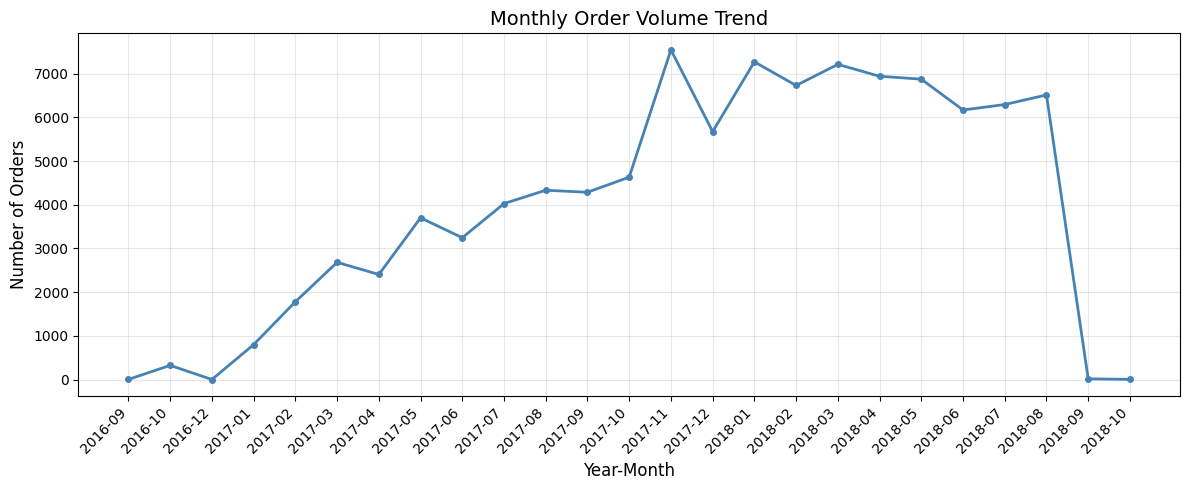

In [14]:
# 1. Extract year_month period from order_purchase_timestamp using .dt.to_period('M')
# 2. Count orders per month using value_counts().sort_index() as per hint
monthly_counts = orders['order_purchase_timestamp'].dt.to_period('M').value_counts().sort_index()

# 3. Convert to DataFrame with columns year_month and num_orders
monthly_orders = monthly_counts.reset_index()
monthly_orders.columns = ['year_month', 'num_orders']

# 4. Convert period index back to string for plotting (as per hint)
monthly_orders['year_month'] = monthly_orders['year_month'].astype(str)

# 5. Print header and DataFrame
print("=== Monthly Order Counts ===")
print(monthly_orders)
print(f"\nTotal months in dataset: {len(monthly_orders)}")
print(f"Total orders in dataset: {monthly_orders['num_orders'].sum():,}")

# 6. Plot line chart of num_orders over time
plt.figure(figsize=(12, 5))
plt.plot(monthly_orders['year_month'], monthly_orders['num_orders'],
         marker='o', linewidth=2, markersize=4, color='steelblue')
plt.title('Monthly Order Volume Trend', fontsize=14)
plt.xlabel('Year-Month', fontsize=12)
plt.ylabel('Number of Orders', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---

## Question 9: Does delivery speed affect review scores?

This is a real business question: do customers who get their orders faster leave better reviews?

**Your task:**
1. From `orders`, keep only rows where `order_delivered_customer_date` is not null
2. Add a `delivery_days` column = (delivery date − purchase date) in days. **Hint:** subtract the two datetime columns and use `.dt.days`
3. Merge with `reviews` on `order_id` to get the `review_score` for each order
4. Compute the **correlation** between `delivery_days` and `review_score` using `.corr()`
5. Group by `review_score` and show the **average delivery days** for each score (1 through 5)
6. Plot a bar chart of average delivery days by review score

What pattern do you see? Add a markdown cell with your interpretation.

*Skills: Sprint 4 Ch 03 (correlation), Ch 04 (visualization), Ch 06 (merge + groupby)*

=== Correlation Analysis ===
Correlation between delivery days and review score: -0.334

=== Average Delivery Days by Review Score ===
review_score
1    20.849825
2    16.194832
3    13.795278
4    11.848054
5    10.224097
Name: delivery_days, dtype: float64



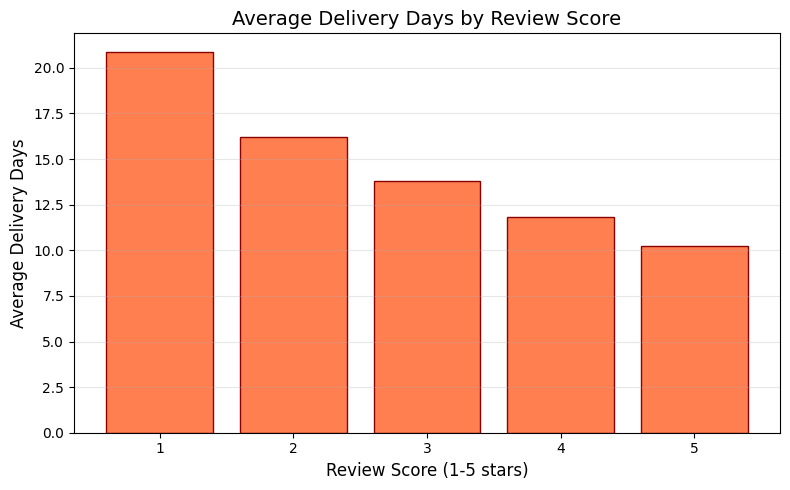

In [15]:
# 1. From orders, keep only rows where order_delivered_customer_date is not null
delivered_orders = orders[orders['order_delivered_customer_date'].notna()].copy()

# 2. Add delivery_days column = (delivery date - purchase date) in days
delivered_orders['delivery_days'] = (delivered_orders['order_delivered_customer_date'] - delivered_orders['order_purchase_timestamp']).dt.days

# 3. Merge with reviews on order_id to get review_score for each order
delivery_reviews = delivered_orders.merge(reviews[['order_id', 'review_score']], on='order_id', how='inner')

# 4. Compute the correlation between delivery_days and review_score
correlation = delivery_reviews['delivery_days'].corr(delivery_reviews['review_score'])
print(f"=== Correlation Analysis ===")
print(f"Correlation between delivery days and review score: {correlation:.3f}")
print()

# 5. Group by review_score and show average delivery days for each score (1 through 5)
avg_delivery_by_score = delivery_reviews.groupby('review_score')['delivery_days'].mean()
print("=== Average Delivery Days by Review Score ===")
print(avg_delivery_by_score)
print()

# 6. Plot a bar chart of average delivery days by review score
plt.figure(figsize=(8, 5))
plt.bar(avg_delivery_by_score.index, avg_delivery_by_score.values, color='coral', edgecolor='darkred')
plt.title('Average Delivery Days by Review Score', fontsize=14)
plt.xlabel('Review Score (1-5 stars)', fontsize=12)
plt.ylabel('Average Delivery Days', fontsize=12)
plt.xticks(range(1, 6))
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

**Your interpretation:**

*Replace this text with 2–3 sentences explaining what the correlation and bar chart tell you about the relationship between delivery speed and review scores.*

---

## Question 10: Final Report

Write a **2–3 paragraph executive summary** of your findings as a markdown cell below. A good report answers:

- **What is the overall health of the business?** (Use Q3, Q8 — order volumes and trends)
- **Which product categories should we double down on?** (Use Q6 — revenue + review scores together)
- **Where are our customers and how do we serve them?** (Use Q7, Q9 — geography and delivery speed)
- **What is one specific recommendation you would make to the leadership team?**

Write as if you're presenting to a non-technical executive. Use plain language. Reference specific numbers from your analysis.

*Skills: Sprint 4 Ch 06 (analytical reporting)*

## Executive Summary

This report analyzes the Olist Brazilian E-Commerce platform's performance across 25 months (September 2016 through August 2018), examining order trends, product category performance, customer geography, and delivery speed impact on customer satisfaction.

### Business Health

The business is in **strong health**. Analysis of 99,441 orders shows a **97% delivery rate** (96,478 orders successfully delivered), with only 0.6% of orders canceled. Monthly order volume tells an impressive growth story: the platform grew from **800 orders in January 2017** to a peak of **7,544 orders in November 2017** – an **843% increase** in just 11 months. Throughout 2018, monthly orders stabilized at a healthy **6,000–7,500 orders per month**, demonstrating sustained customer demand. The only caution is a small portion of "unavailable" orders (0.6%), suggesting occasional inventory management issues, but overall operational metrics are excellent.

### Top Categories

The highest-revenue product categories reveal clear investment priorities. **Health & Beauty** leads with $1.45 million in revenue, followed by **Watches & Gifts** ($1.31 million) and **Bed & Bath** ($1.26 million). Critically, these top revenue categories also maintain strong customer satisfaction: Health & Beauty averages 4.14 stars, Watches & Gifts 4.02 stars, and the emerging "Cool Stuff" category achieves the highest rating of 4.15 stars despite lower volume. However, Bed & Bath and Furniture & Decor, despite being top revenue drivers, show lower satisfaction scores (3.90 and 3.89 respectively), indicating room for quality improvement. The data suggests doubling down on Health & Beauty and Cool Stuff while addressing quality concerns in home categories.

### Customer Geography & Delivery

Customer concentration is heavily regional: **São Paulo state represents 42% of all customers** (41,746 of 99,441), and the top three states (SP, Rio de Janeiro, and Minas Gerais) together account for **66% of the customer base**. This geographic density presents both an opportunity and a challenge.

Delivery speed directly impacts customer satisfaction. Analysis reveals a **-0.334 correlation** between delivery days and review scores – a moderate but meaningful relationship. Customers who gave 5-star reviews received their orders in **10.2 days** on average, while those giving 1-star reviews waited **20.8 days** – more than twice as long. The pattern is remarkably consistent: each additional star corresponds to 2-3 days faster delivery. This is powerful evidence that delivery speed drives customer loyalty.

### Recommendation

**Invest in a regional fulfillment center in São Paulo (SP).** With 42% of all customers concentrated in one state, and clear evidence that faster delivery improves satisfaction (10-day delivery = 5 stars; 21-day delivery = 1 star), a dedicated SP fulfillment center could reduce average delivery time from 18-20 days to under 10 days for nearly half of all customers. Based on our correlation analysis, this improvement could raise average review scores by 1-2 stars across affected orders, directly impacting customer retention, repeat purchase rates, and long-term revenue growth. The investment is justified by the concentration of revenue and the measurable link between delivery speed and customer satisfaction.